# Underfitting / Overfitting regularization

Adapted by <alberto.suarez@uam.es>

from
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html#sphx-glr-auto-examples-model-selection-plot-underfitting-overfitting-py


In [1]:
# Import the necessary modules

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn import linear_model
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer


# Plotting utilities

def plot_results(ax,
                 X_train, y_train, 
                 X_test, y_test, y_test_pred,
                 scores, score_test):
 
    # Plot results
       
 
    ax.scatter(X_train, y_train, edgecolor='b', s=20, label='Training data')
    y_plot_min, y_plot_max  = ax.get_ylim()

    ax.plot(X_test, y_test, label='True function')
    ax.plot(X_test, y_test_pred, label='Model') 

    ax.set_xlabel('x', fontsize=fontsize)
    ax.set_ylabel('y', fontsize=fontsize)
    ax.legend(loc='best')
    
    ax.set_ylim(y_plot_min, y_plot_max)
    
    ax.set_title('MSE test = {:.2e}  \nMSE CV (stdev)= {:.2e} ({:.2e} )'.format(
        score_test, - np.mean(scores), np.std(scores)), fontsize=fontsize)
    
    
def evaluate_plot_results(pipeline, 
                          X_train, y_train,
                          X_test, y_test,
                          score_metric,
                          cv,
                          n_columns_plot):

    
    # Evaluate the model using k-fold cross-validation
    scorer = make_scorer(score_metric, greater_is_better=False)
    cv = 10
    scores_cv = cross_val_score(pipeline, 
                                X_train[:, np.newaxis], y_train,
                                scoring=scorer, 
                                cv=cv)
       
    # Compute predictions on the test set
    y_test_pred = pipeline.predict(X_test[:, np.newaxis])
    score_test = score_metric(y_test, y_test_pred)
    
    # Plot results
    n_row_plot = n // n_columns_plot    
    n_column_plot = n % n_columns_plot
  
    ax = axs[n_row_plot, n_column_plot]
    plot_results(ax,
                 X_train, y_train, 
                 X_test, y_test, y_test_pred,
                 scores_cv, score_test) 
    return ax


## Non-linear noisy regression problem 

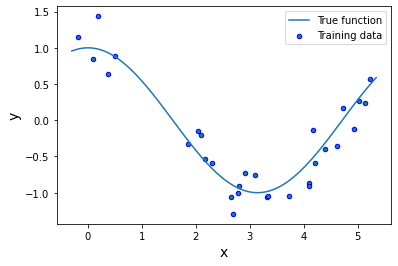

In [2]:
# Underlying funtion
def true_function(X):
    return np.cos(X)

## Generate training data

n_train = 30

# Uniform distribution in an interval
x_min = -0.3
x_max = 1.7 * np.pi

np.random.seed(0)
X_train = np.sort(x_min + (x_max-x_min)*np.random.rand(n_train))

# Noise parameters,
sigma_noise = 0.2
noise = sigma_noise*np.random.randn(n_train)

# Noisy target
y_train = true_function(X_train) +  noise

## Generate test data

n_test = 100 
X_test = np.linspace(x_min, x_max, n_test)
y_test = true_function(X_test)

## Plot the training data together with the true function as a reference

fontsize = 14

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

plt.scatter(X_train, y_train, edgecolor='b', s=20, label='Training data')
ax.plot(X_test, y_test, label='True function')

_ = ax.set_xlabel('x', fontsize=fontsize)
_ = ax.set_ylabel('y', fontsize=fontsize)
_ = ax.legend()

## Polynomial fit

Model: Polynominal

Cost function: mean-squared error (MSE)


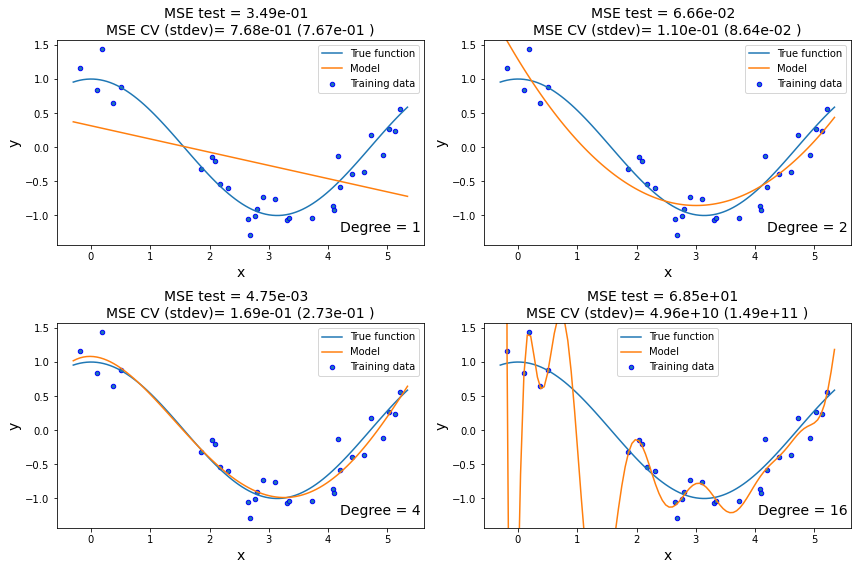

In [3]:
# Number of cross-validation folds
cv = 10

# Degrees of the polynomials used in the fit 

degrees = [1, 2, 4, 16]


# Plot setup 
n_rows_plot = 2
n_columns_plot = 2
fig, axs = plt.subplots(n_rows_plot, 
                        n_columns_plot, 
                        figsize=(12, 8)) 

for n, degree in enumerate(degrees):
    
    # Initialize an instance of Pipeline
    polynomial_features = PolynomialFeatures(degree=degree,
                                             include_bias=False)
    regressor = linear_model.LinearRegression()
    
    scaler = StandardScaler()
    
    pipeline = Pipeline([('polynomial_features', polynomial_features),
                         ('scaler', scaler),
                         ('linear_regressor', regressor)])

    # Train model : sklearn predictors expect a data matrix
    # where each row corresponds to a training sample,
    # each column to a feature
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate model
    
    score_metric = mean_squared_error
    
    ax = evaluate_plot_results(pipeline, 
                               X_train, y_train,
                               X_test, y_test,
                               score_metric=score_metric,
                               cv=cv,
                               n_columns_plot=n_columns_plot)
   
    ax.text(0.99, 0.05, 'Degree = {}'.format(degree),
            horizontalalignment='right',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=14)

    
fig.tight_layout(pad=1.0)
    

## Regularization: ridge regression

Model: Polynominal

Cost function: MSE + $\alpha$ ($L_2$ penalty) 

https://scikit-learn.org/stable/modules/linear_model.html

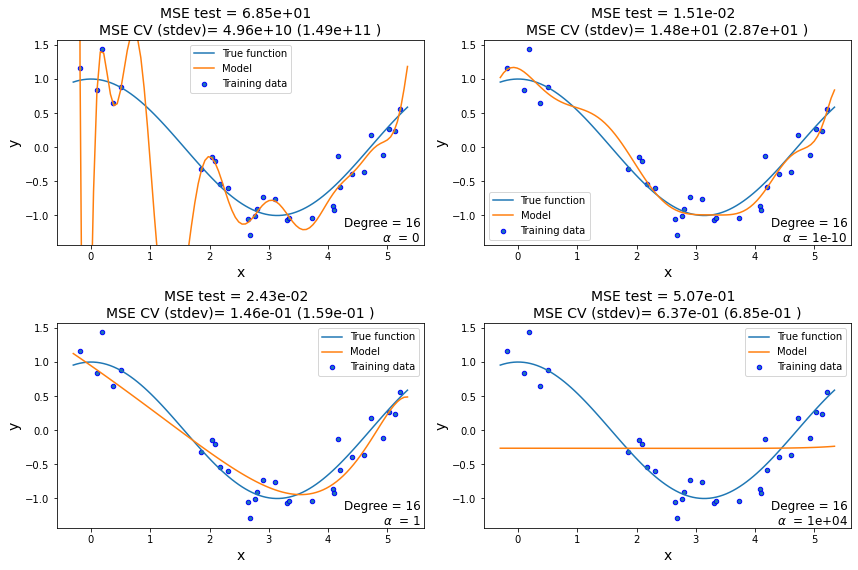

In [4]:
# Model parameters 
degree = 16
alphas = [0.0, 1.0e-10, 1.0, 1.0e4] # default for Ridge is 1.0

# Setup plot
n_rows_plot = 2
n_columns_plot = 2
fig, axs = plt.subplots(n_rows_plot, 
                        n_columns_plot, 
                        figsize=(12, 8)) 

for n, alpha in enumerate(alphas):

    # Initialize an instance of Pipeline
    polynomial_features = PolynomialFeatures(degree=degree,
                                             include_bias=False)
    regressor = linear_model.Ridge(alpha)   
    scaler = StandardScaler()
    
    pipeline = Pipeline([('polynomial_features', polynomial_features),
                         ('scaler', scaler),
                         ('linear_ridge_regressor', regressor)])

    # Train model : sklearn predictors expect a data matrix
    # where each row corresponds to a training sample,
    # each column to a feature
    pipeline.fit(X_train[:, np.newaxis], y_train)

    # Evaluate model
    
    score_metric = mean_squared_error
    
    ax = evaluate_plot_results(pipeline, 
                               X_train, y_train,
                               X_test, y_test,
                               score_metric=score_metric,
                               cv=cv,
                               n_columns_plot=n_columns_plot)
       
    ax.text(0.99, 0.0, 'Degree = {}\n'.format(degree) + r'$\alpha$  = {:.0g}'.format(alpha),
            horizontalalignment='right',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=12)
  
fig.tight_layout(pad=1.0)

    


## Regularization: Neural networks

Model: Neural network

Cost function: MSE + $\alpha$ ($L_2$ penalty) 

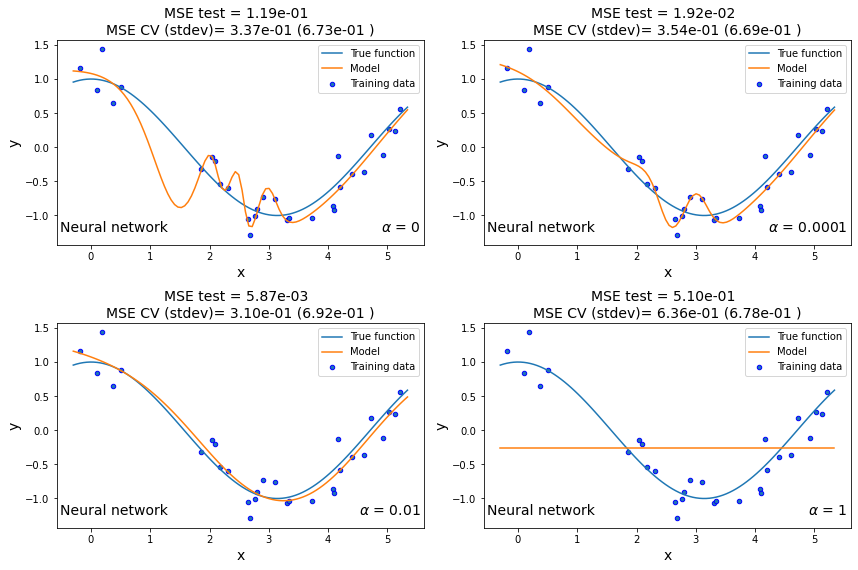

In [5]:
## $L_2$ Regularization for neural network

# Neural network architecure and hyparameters 

hidden_layer_sizes=(100, 20)
activation='logistic'
alphas = [0.0, 1.0e-4, 1.0e-2, 1.0] # default is 1.0e-4
solver = 'lbfgs'

# Comment to view warnings 
import warnings
warnings.filterwarnings('ignore')


# Setup plot
n_rows_plot = 2
n_columns_plot = 2
fig, axs = plt.subplots(n_rows_plot, 
                        n_columns_plot, 
                        figsize=(12, 8)) 

for n, alpha in enumerate(alphas):

    # Initialize an instance of Pipeline

    # The initial weights of the neural network are initialized at random
    np.random.seed(0) # For reproducibility

    regressor = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                             activation=activation,
                             solver=solver,
                             alpha=alpha)
    
    scaler = StandardScaler()
    
    pipeline = Pipeline([('scaler', scaler),
                         ('MLP_regressor', regressor)])

    # Train model : sklearn predictors expect a data matrix
    # where each row corresponds to a training sample,
    # each column to a feature
    pipeline.fit(X_train[:, np.newaxis], y_train)
    
    # Evaluate model
    
    score_metric = mean_squared_error
    
    ax = evaluate_plot_results(pipeline, 
                               X_train, y_train,
                               X_test, y_test,
                               score_metric=score_metric,
                               cv=cv,
                               n_columns_plot=n_columns_plot)
    
    ax.text(0.99, 0.05, r'$\alpha$ = {:.0g}'.format(alpha),
            horizontalalignment='right',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=14)
    
    ax.text(0.01, 0.05, 'Neural network',
            horizontalalignment='left',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=14)

    
fig.tight_layout(pad=1.0)



## Regularization: Support vector machines

Model: Support vector regression

Cost function: SVR cost function with $L_2$ penalty 

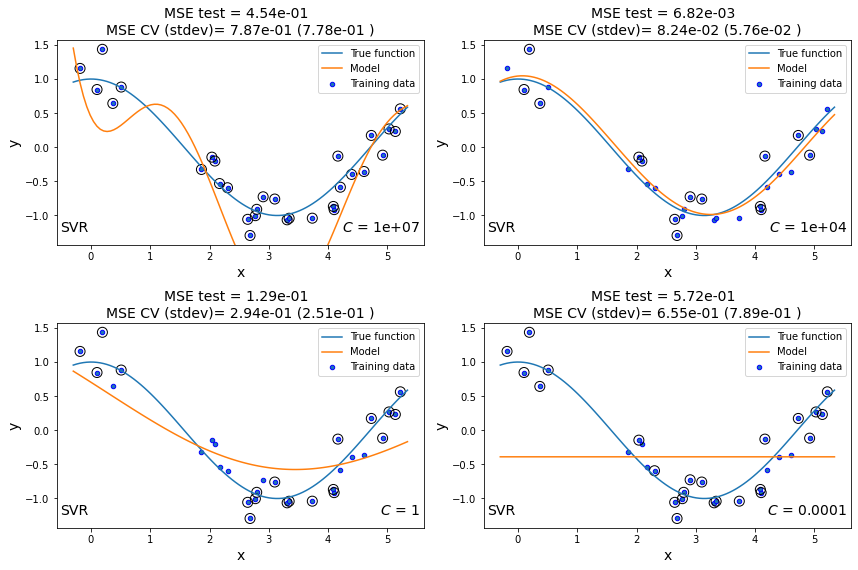

In [13]:
# SVR hyparameters 

kernel = 'rbf' # RBF = radial basis function
gamma = 1.0    # inverse of the kernel width
C = 1.0        # Inversely proportional of the strength of the l2 penalty
epsilon = 0.2  # size of epsilon-tube within which there is no penalty

Cs = [1.0e7, 1.0e4, 1.0, 1.0e-4] # Larger C = less regularization

np.random.seed(0)

# Setup plot
n_rows_plot = 2
n_columns_plot = 2
fig, axs = plt.subplots(n_rows_plot, 
                        n_columns_plot, 
                        figsize=(12, 8)) 

for n, C in enumerate(Cs):

    # Initialize an instance of Pipeline

    regressor = SVR(kernel=kernel, gamma=gamma, 
                    C=C, 
                    epsilon=epsilon)
         
    scaler = MinMaxScaler()    
   
    pipeline = Pipeline([('scaler', scaler),
                         ('SVM_regressor', regressor)])

    # Train model : sklearn predictors expect a data matrix
    # where each row corresponds to a training sample,
    # each column to a feature
    pipeline.fit(X_train[:, np.newaxis], y_train)

    
    # Evaluate model and plot results of the evaluation
    
    score_metric = mean_squared_error
    
    ax = evaluate_plot_results(pipeline, 
                               X_train, y_train,
                               X_test, y_test,
                               score_metric=score_metric,
                               cv=cv,
                               n_columns_plot=n_columns_plot)

    # Transform Back to the original representation.    
    support_vectors = pipeline['scaler'].inverse_transform(
        pipeline['SVM_regressor'].support_vectors_)
    
    support_index = pipeline['SVM_regressor'].support_
    
    ax.scatter(X_train[support_index], y_train[support_index], 
               s=100, linewidth=1, facecolors='none', edgecolors='k')

    ax.text(0.99, 0.05, r'$C$ = {:.0g}'.format(C),
            horizontalalignment='right',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=14)

    ax.text(0.01, 0.05, 'SVR',
            horizontalalignment='left',
            verticalalignment='bottom',
            transform=ax.transAxes,
            fontsize=14)

fig.tight_layout(pad=1.0)